# Delay Patterns

This notebook describes when delays occur and how delay rates differ across airlines, destinations, and flight characteristics for one airport-year.

The analysis uses both targets as outcomes. Actual departure and arrival fields can be used here to describe what happened, even though some of them will be excluded from pre-pushback model inputs.

In [1]:
from pathlib import Path
import sys

EDA_DIR = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd() / "eda"
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import AIRPORT, FIGURE_DPI, RANDOM_STATE, SCATTER_SAMPLE_SIZE, TOP_CATEGORIES, YEAR
from eda_utils import (
    TARGET_COLUMNS,
    WEATHER_FLAGS,
    add_eda_columns,
    category_rate,
    load_merged,
    safe_sample,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = FIGURE_DPI
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

df = add_eda_columns(load_merged(AIRPORT, YEAR))
print(f"Loaded {AIRPORT}_{YEAR}: {len(df):,} flights and {df.shape[1]:,} columns after EDA helpers.")

Loaded JFK_2019: 124,759 flights and 70 columns after EDA helpers.


## Delay rate by month

Monthly rates show seasonality and identify parts of the year with unusually high or low delay risk.

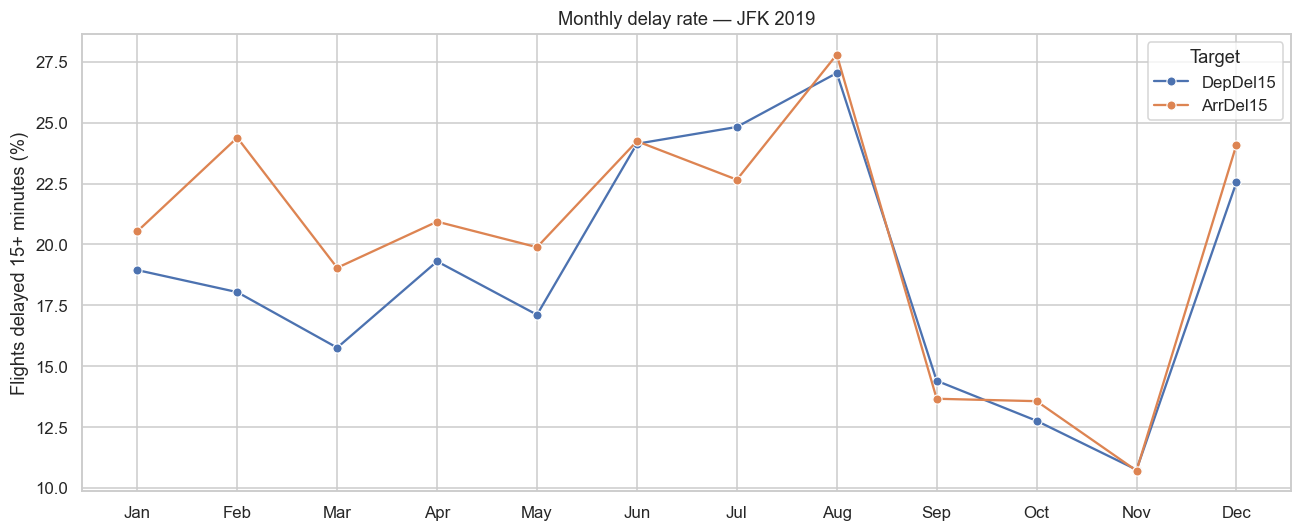

In [2]:
monthly = (
    df.groupby(["Month", "MonthName"], observed=True)[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("Month")
)
monthly_long = monthly.melt(
    id_vars=["Month", "MonthName"],
    value_vars=list(TARGET_COLUMNS),
    var_name="Target",
    value_name="DelayRate",
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_long, x="Month", y="DelayRate", hue="Target", marker="o")
plt.xticks(monthly["Month"].unique(), monthly["MonthName"].unique())
plt.title(f"Monthly delay rate — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Delay rate by day of week

This chart checks whether weekday and weekend operations have different delay patterns.

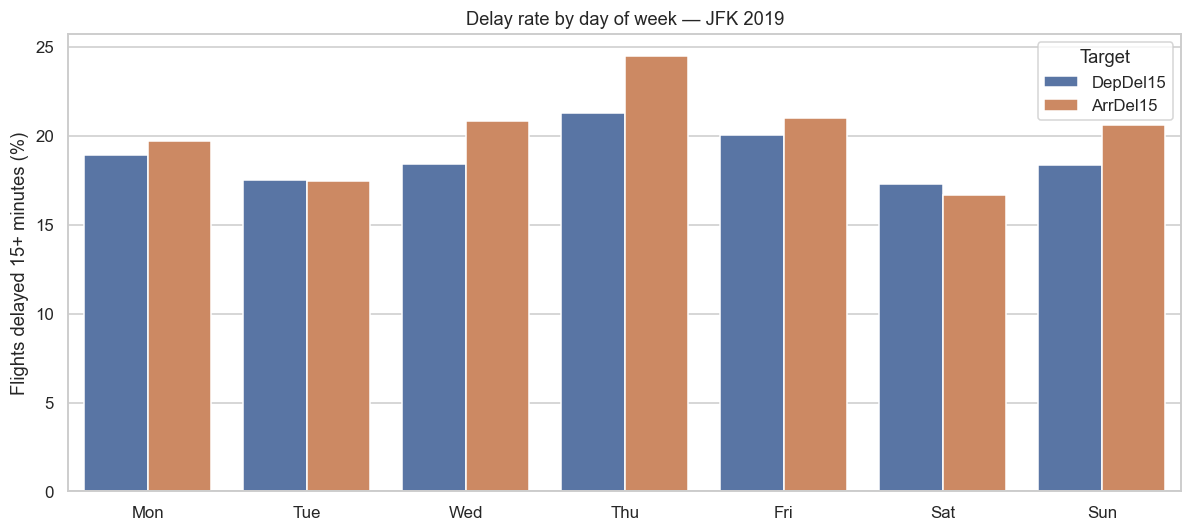

In [3]:
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_rates = (
    df.groupby("DayName", observed=True)[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reindex(day_order)
    .reset_index()
    .melt(id_vars="DayName", var_name="Target", value_name="DelayRate")
)

plt.figure(figsize=(11, 5))
sns.barplot(data=day_rates, x="DayName", y="DelayRate", hue="Target", order=day_order)
plt.title(f"Delay rate by day of week — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Delay rate by scheduled departure hour

Hourly rates can reveal peak-period congestion and whether delay risk builds through the operating day.

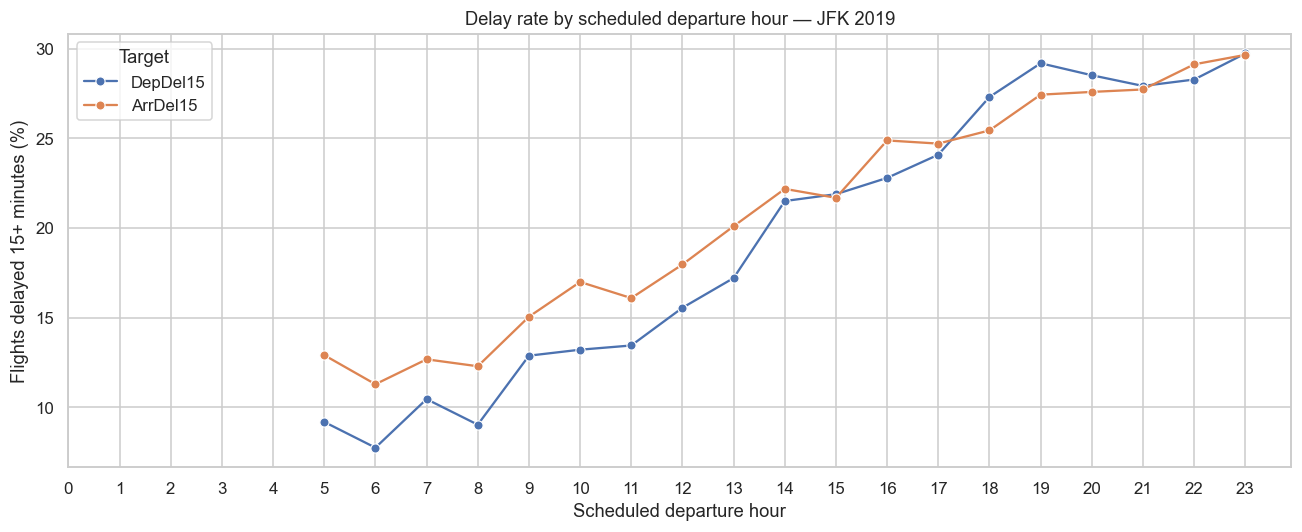

In [4]:
hourly = (
    df.groupby("ScheduledDepartureHour")[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reset_index()
    .melt(
        id_vars="ScheduledDepartureHour",
        var_name="Target",
        value_name="DelayRate",
    )
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=hourly,
    x="ScheduledDepartureHour",
    y="DelayRate",
    hue="Target",
    marker="o",
)
plt.xticks(range(0, 24))
plt.title(f"Delay rate by scheduled departure hour — {AIRPORT} {YEAR}")
plt.xlabel("Scheduled departure hour")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Broad time-of-day comparison

The time-of-day groups are descriptive labels created for EDA. Later models may use more precise cyclical hour features instead.

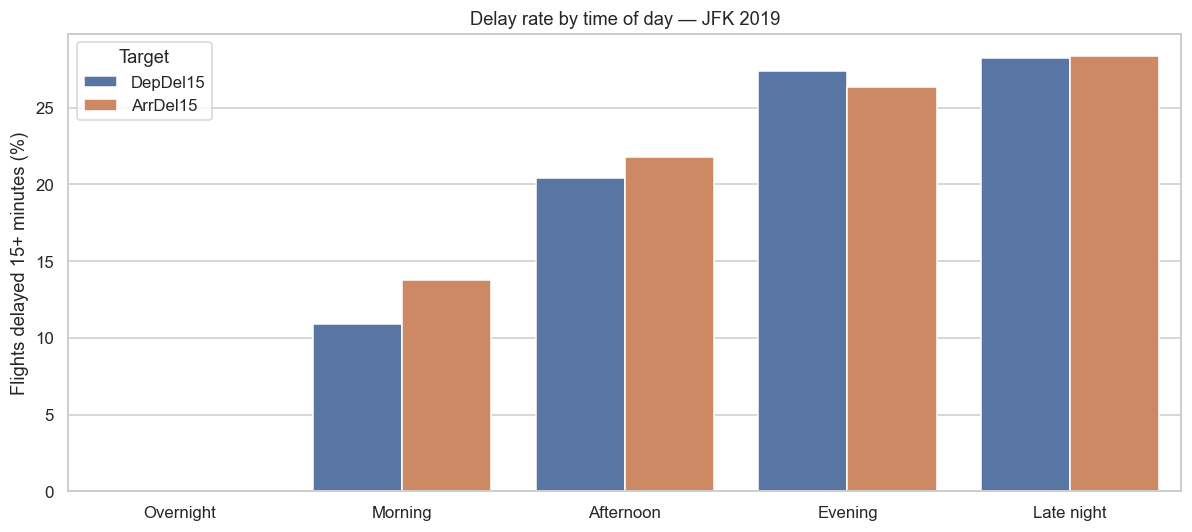

In [5]:
time_order = ["Overnight", "Morning", "Afternoon", "Evening", "Late night"]
time_rates = (
    df.groupby("TimeOfDay", observed=True)[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reindex(time_order)
    .reset_index()
    .melt(id_vars="TimeOfDay", var_name="Target", value_name="DelayRate")
)

plt.figure(figsize=(11, 5))
sns.barplot(data=time_rates, x="TimeOfDay", y="DelayRate", hue="Target", order=time_order)
plt.title(f"Delay rate by time of day — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Airlines

Only the busiest airlines are shown so that small groups do not dominate the comparison. Flight counts are displayed alongside delay rates because a high rate based on very few flights can be misleading.

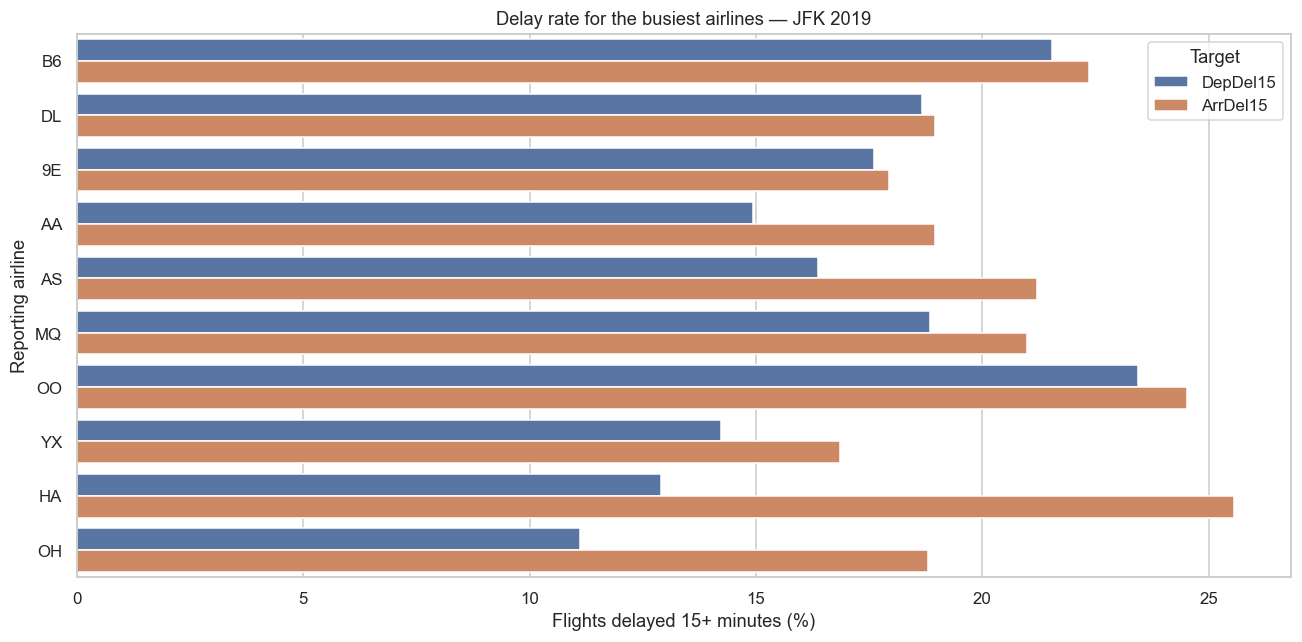

,Flights
Reporting_Airline,
B6,40965
DL,32298
9E,20616
AA,15332
AS,4983
MQ,4551
OO,2765
YX,2651
HA,364


In [6]:
top_airlines = df["Reporting_Airline"].value_counts().head(TOP_CATEGORIES).index
airline_rates = (
    df.loc[df["Reporting_Airline"].isin(top_airlines)]
    .groupby("Reporting_Airline")[list(TARGET_COLUMNS)]
    .agg(["size", "mean"])
)

airline_plot = (
    df.loc[df["Reporting_Airline"].isin(top_airlines)]
    .groupby("Reporting_Airline")[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reset_index()
    .melt(id_vars="Reporting_Airline", var_name="Target", value_name="DelayRate")
)
airline_order = df["Reporting_Airline"].value_counts().loc[top_airlines].index

plt.figure(figsize=(12, 6))
sns.barplot(
    data=airline_plot,
    x="DelayRate",
    y="Reporting_Airline",
    hue="Target",
    order=airline_order,
)
plt.title(f"Delay rate for the busiest airlines — {AIRPORT} {YEAR}")
plt.xlabel("Flights delayed 15+ minutes (%)")
plt.ylabel("Reporting airline")
plt.tight_layout()
plt.show()

display(
    df["Reporting_Airline"]
    .value_counts()
    .loc[top_airlines]
    .rename("Flights")
    .to_frame()
)

## Destinations

Destination can represent differences in route length, schedules, and conditions at the arrival airport. This view is limited to the busiest destinations for readability.

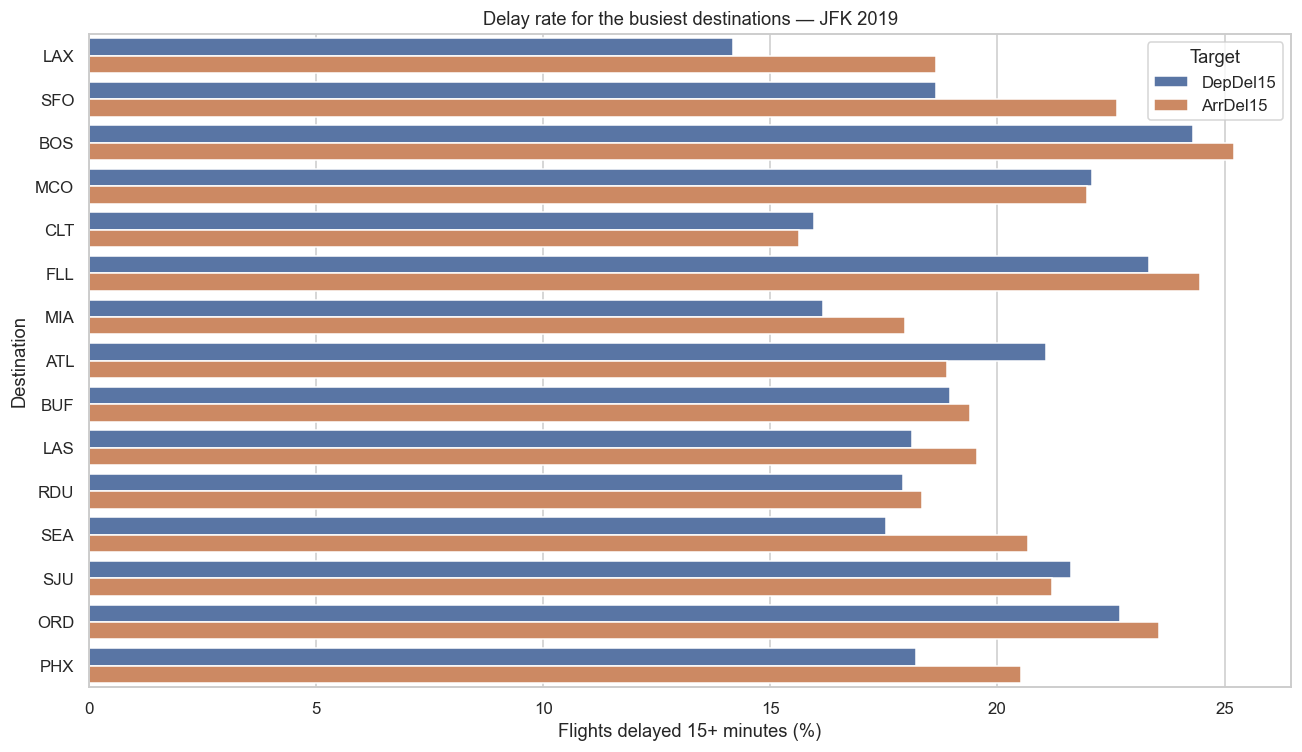

In [7]:
top_destinations = df["Dest"].value_counts().head(TOP_CATEGORIES).index
destination_plot = (
    df.loc[df["Dest"].isin(top_destinations)]
    .groupby("Dest")[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reset_index()
    .melt(id_vars="Dest", var_name="Target", value_name="DelayRate")
)
destination_order = df["Dest"].value_counts().loc[top_destinations].index

plt.figure(figsize=(12, 7))
sns.barplot(
    data=destination_plot,
    x="DelayRate",
    y="Dest",
    hue="Target",
    order=destination_order,
)
plt.title(f"Delay rate for the busiest destinations — {AIRPORT} {YEAR}")
plt.xlabel("Flights delayed 15+ minutes (%)")
plt.ylabel("Destination")
plt.tight_layout()
plt.show()

## Distance group

Distance groups provide a simple view of whether short-, medium-, and long-distance flights have different delay rates.

DepDel15       ArrDel15      
                  size  mean     size  mean
DistanceGroup                              
1                13476 0.208    13476 0.220
2                19394 0.187    19394 0.193
3                13269 0.186    13269 0.188
4                11694 0.210    11694 0.201
5                16515 0.189    16515 0.199
6                 2315 0.216     2315 0.237
7                 8369 0.221     8369 0.217
8                 2676 0.193     2676 0.182
9                 6169 0.182     6169 0.200
10               21346 0.154    21346 0.192
11                9536 0.188     9536 0.225

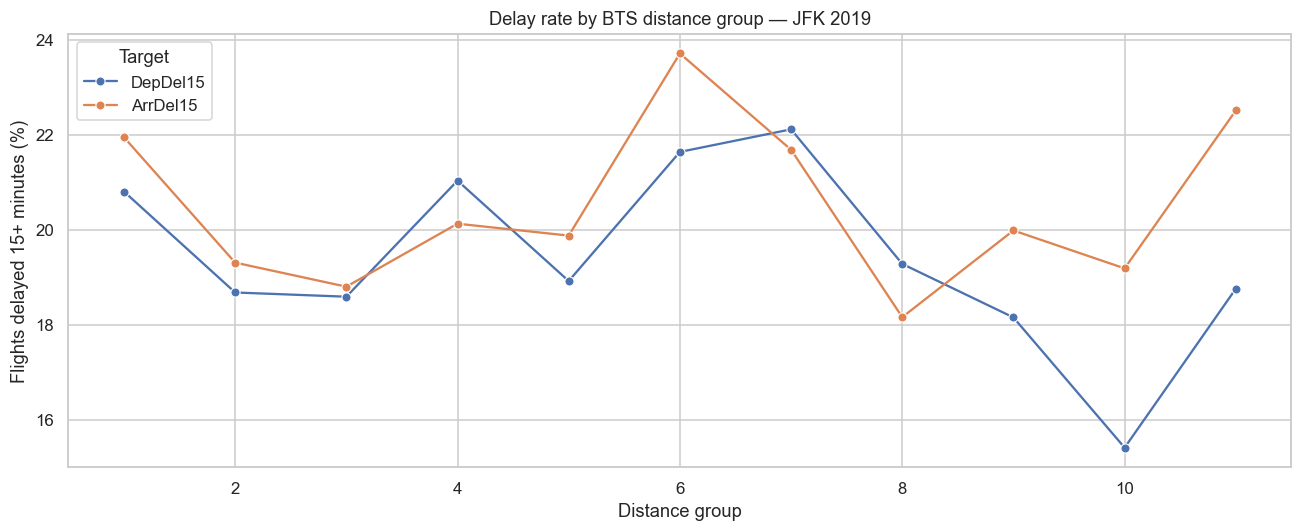

In [8]:
distance_rates = (
    df.groupby("DistanceGroup")[list(TARGET_COLUMNS)]
    .agg(["size", "mean"])
)
display(distance_rates)

distance_plot = (
    df.groupby("DistanceGroup")[list(TARGET_COLUMNS)]
    .mean()
    .mul(100)
    .reset_index()
    .melt(id_vars="DistanceGroup", var_name="Target", value_name="DelayRate")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=distance_plot,
    x="DistanceGroup",
    y="DelayRate",
    hue="Target",
    marker="o",
)
plt.title(f"Delay rate by BTS distance group — {AIRPORT} {YEAR}")
plt.xlabel("Distance group")
plt.ylabel("Flights delayed 15+ minutes (%)")
plt.tight_layout()
plt.show()

## Relationship between departure and arrival outcomes

This table and heatmap show how often departure and arrival classifications agree. The comparison motivates Models 2A and 2B: Model 2B tests how much arrival prediction improves after the departure outcome becomes known.

ArrDel15,Arrival delayed,Arrival on time
DepDel15,,
Departure delayed,14.290,4.583
Departure on time,5.878,75.249


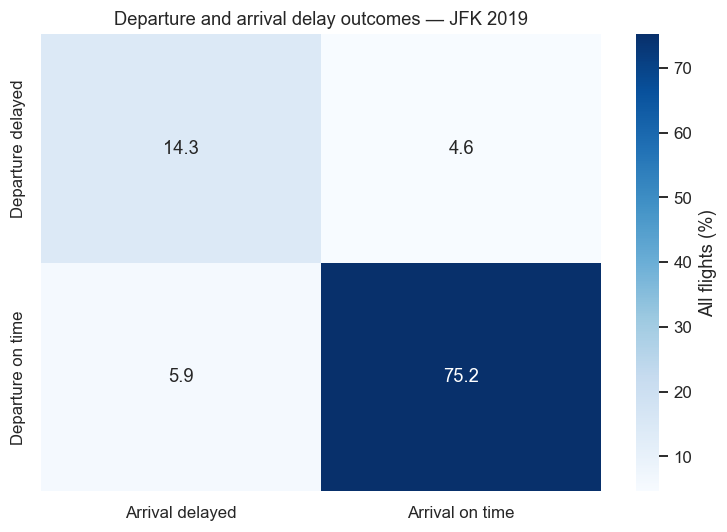

In [9]:
delay_pair = pd.crosstab(
    df["DepDel15"].map({0.0: "Departure on time", 1.0: "Departure delayed"}),
    df["ArrDel15"].map({0.0: "Arrival on time", 1.0: "Arrival delayed"}),
    normalize="all",
).mul(100)

display(delay_pair)

plt.figure(figsize=(7, 5))
sns.heatmap(delay_pair, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "All flights (%)"})
plt.title(f"Departure and arrival delay outcomes — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Departure-delay duration

This outcome distribution describes the size of observed departure delays. The upper one percent is omitted from the chart so that ordinary delays remain visible. `DepDelayMinutes` is an outcome and cannot be used by Models 1 or 2A; it becomes available only for Model 2B after pushback.

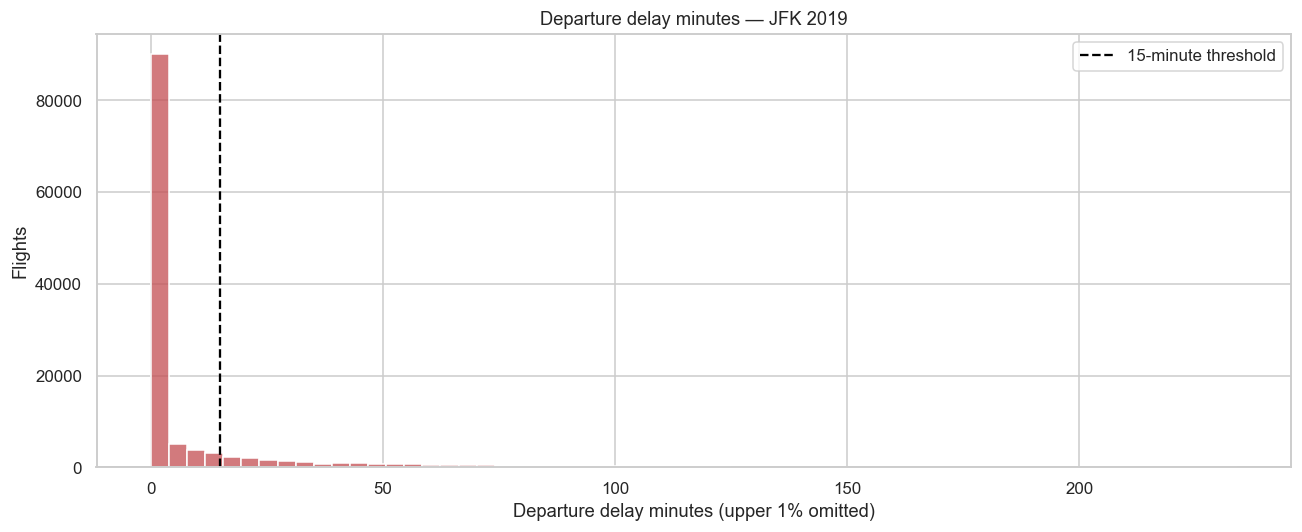

In [10]:
upper_delay = df["DepDelayMinutes"].quantile(0.99)
delay_minutes = df.loc[
    df["DepDelayMinutes"].between(0, upper_delay),
    "DepDelayMinutes",
]

plt.figure(figsize=(12, 5))
sns.histplot(delay_minutes, bins=60, color="#C44E52")
plt.axvline(15, color="black", linestyle="--", label="15-minute threshold")
plt.title(f"Departure delay minutes — {AIRPORT} {YEAR}")
plt.xlabel("Departure delay minutes (upper 1% omitted)")
plt.ylabel("Flights")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation guide

Look for patterns that are consistent enough to investigate across other airports and years. Differences in raw delay rates do not prove that an airline, destination, hour, or distance caused a delay. They identify useful questions for the cross-airport analysis and later modeling.